# Autocorrelación Espacial Global (*Global Spatial Autocorrelation*)

**Adaptado de:** Rey, Arribas-Bel & Wolf – *Geographic Data Science with Python*, Capítulo 6.

# 1. Entendiendo la autocorrelación espacial

La **autocorrelación espacial** se refiere a la existencia de una relación funcional entre lo que ocurre en un punto del espacio y lo que ocurre en otros lugares. El concepto examina cómo la similitud en los **valores** de una variable se correlaciona con la similitud en las **ubicaciones** geográficas.

A diferencia de la autocorrelación temporal, la autocorrelación espacial conecta los valores de una variable en una ubicación dada con los valores de la **misma variable** en otras ubicaciones.

La **aleatoriedad espacial** representa una condición base donde la ubicación no proporciona información sobre el valor de la variable. La autocorrelación espacial se define como la **ausencia de aleatoriedad espacial**.

La autocorrelación espacial se manifiesta en dos dimensiones: **signo** y **escala**.

### Autocorrelación espacial positiva

Ocurre cuando valores similares se **agrupan** geográficamente. Por ejemplo, en la distribución del ingreso, las áreas de altos ingresos tienden a estar cerca de otras áreas de altos ingresos, y la pobreza se concentra en regiones específicas.

### Autocorrelación espacial negativa

Ocurre cuando valores similares se distribuyen **lejos unos de otros**. Aparece en escenarios de competencia espacial, como la localización de instalaciones (supermercados, hospitales).

### Global vs. Local

- **Autocorrelación global:** examina las tendencias espaciales generales. ¿Siguen los valores patrones geográficos particulares? ¿Están los valores similares más cerca de lo que el azar predeciría?
- **Autocorrelación local:** se enfoca en desviaciones de las tendencias globales a escalas más pequeñas.

En este notebook utilizaremos herramientas de **Análisis Exploratorio de Datos Espaciales** (ESDA), que son análogas al análisis exploratorio de datos tradicional.

# 2. Ilustración empírica: el Referéndum de la UE (Brexit)

El **referéndum del Brexit** de 2016 en el Reino Unido es nuestro ejemplo empírico. Combinamos los datos de la **Comisión Electoral** (porcentajes de voto a nivel de autoridad local) con los límites geográficos de los **Distritos de Autoridad Local** (LAD) de la ONS.

La variable principal que analizaremos es `Pct_Leave`, que mide la **proporción de votos a favor de abandonar la UE**.

## 2.1 Configuración e importación de librerías

In [1]:
# Gráficos
import matplotlib.pyplot as plt
import seaborn
import splot
from splot.esda import plot_moran
import contextily

# Análisis
import geopandas
import pandas as pd
import esda
from libpysal import weights
from numpy.random import seed

## 2.2 Carga y preparación de datos

In [2]:
# Cargar resultados del referéndum (CSV)
brexit_data_path = "datos/external/brexit/brexit_vote.csv"
ref = pd.read_csv(brexit_data_path, index_col="Area_Code")
ref.head()

,id,Region_Code,Region,Area,Electorate,ExpectedBallots,VerifiedBallotPapers,Pct_Turnout,Votes_Cast,Valid_Votes,Remain,Leave,Rejected_Ballots,No_official_mark,Voting_for_both_answers,Writing_or_mark,Unmarked_or_void,Pct_Remain,Pct_Leave,Pct_Rejected
Area_Code,,,,,,,,,,,,,,,,,,,,
E06000031,108,E12000006,East,Peterborough,120892,87474,87469,72.35,87469,87392,34176,53216,77,0,32,7,38,39.11,60.89,0.09
E06000032,109,E12000006,East,Luton,127612,84633,84636,66.31,84616,84481,36708,47773,135,0,85,0,50,43.45,56.55,0.16
E06000033,112,E12000006,East,Southend-on-Sea,128856,93948,93939,72.90,93939,93870,39348,54522,69,0,21,0,48,41.92,58.08,0.07
E06000034,113,E12000006,East,Thurrock,109897,79969,79954,72.75,79950,79916,22151,57765,34,0,8,3,23,27.72,72.28,0.04
E06000055,110,E12000006,East,Bedford,119530,86136,86136,72.06,86135,86066,41497,44569,69,0,26,1,42,48.22,51.78,0.08


In [3]:
# Cargar límites geográficos de los distritos de autoridad local (GeoJSON)
lads = geopandas.read_file(
    "datos/external/brexit/local_authority_districts.geojson"
).set_index("lad16cd")
lads.head()

,objectid,lad16nm,lad16nmw,bng_e,bng_n,long,lat,st_areasha,st_lengths,geometry
lad16cd,,,,,,,,,,
E06000001,1,Hartlepool,None,447157,531476,-1.27023,54.676159,0.013041,0.879421,"MULTIPOLYGON (((-1.27024 54.72716, -1.38088 54..."
E06000002,2,Middlesbrough,None,451141,516887,-1.21099,54.544670,0.007484,0.535764,"MULTIPOLYGON (((-1.23001 54.58410, -1.28158 54..."
E06000003,3,Redcar and Cleveland,None,464359,519597,-1.00611,54.567520,0.034014,1.266847,"MULTIPOLYGON (((-1.13716 54.64693, -1.13256 54..."
E06000004,4,Stockton-on-Tees,None,444937,518183,-1.30669,54.556911,0.028479,1.424195,"MULTIPOLYGON (((-1.31774 54.64524, -1.38088 54..."
E06000010,10,"Kingston upon Hull, City of",None,511894,431716,-0.30380,53.769791,0.009740,0.782168,"MULTIPOLYGON (((-0.31613 53.81325, -0.35366 53..."


In [4]:
# Combinar datos electorales con geometrías
db = (
    geopandas.GeoDataFrame(
        lads.join(ref[["Pct_Leave"]]), crs=lads.crs
    )
    .to_crs(epsg=3857)[
        ["objectid", "lad16nm", "Pct_Leave", "geometry"]
    ]
    .dropna()
)
db.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 380 entries, E06000001 to W06000023
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   objectid   380 non-null    int64   
 1   lad16nm    380 non-null    object  
 2   Pct_Leave  380 non-null    float64 
 3   geometry   380 non-null    geometry
dtypes: float64(1), geometry(1), int64(1), object(1)
memory usage: 14.8+ KB


In [5]:
db[db.index.isin(['E08000012', 'S12000019'])]

,objectid,lad16nm,Pct_Leave,geometry
lad16cd,,,,
E08000012,269,Liverpool,41.81,"POLYGON ((-325344.601 7071341.188, -334933.772..."
S12000019,348,Midlothian,37.94,"POLYGON ((-343818.131 7544768.915, -347054.708..."


## 2.3 Mapa coroplético del % Leave

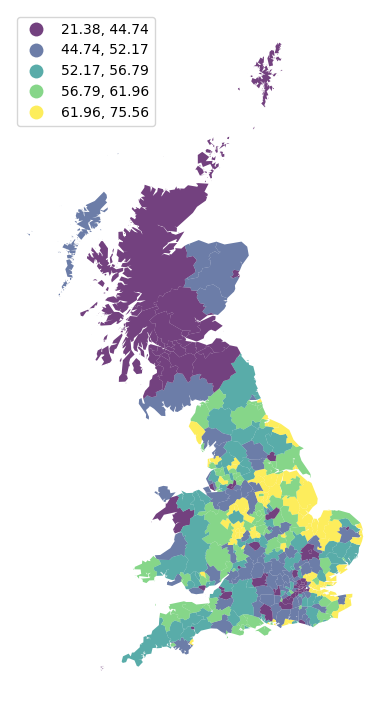

In [6]:
f, ax = plt.subplots(1, figsize=(9, 9))
db.plot(
    column="Pct_Leave",
    cmap="viridis",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.0,
    alpha=0.75,
    legend=True,
    legend_kwds={"loc": 2},
    ax=ax,
)
ax.set_axis_off()
#ax.plot(lx, ly, marker="*", color="red", markersize=12, zorder=5)
#ax.annotate("Liverpool", xy=(lx, ly), xytext=(lx + 5000, ly + 8000),
            #fontsize=9, color="red", fontweight="bold")

plt.show()

El mapa sugiere la presencia de **autocorrelación espacial positiva**: los porcentajes altos de Leave se agrupan en las regiones del este de Inglaterra, mientras que los porcentajes bajos se concentran en Escocia y Londres.

Sin embargo, los seres humanos somos muy buenos detectando patrones — incluso en datos aleatorios. Los mapas coropléticos pueden distorsionar la percepción a través de variaciones en forma y tamaño. Por eso necesitamos **estadísticos formales** para evaluar si los patrones observados superan lo que el azar produciría.

## 2.4 Construcción de la matriz de pesos espaciales

In [7]:
# Generar W de k-vecinos más cercanos (k=8)
w = weights.KNN.from_dataframe(db, k=8)
# Estandarización por filas
w.transform = "R"

### ¿Qué hace `w.transform = "R"`?

La matriz W binaria asigna 1 a cada par de vecinos y 0 al resto.
El problema es que las unidades con más vecinos tienen más peso total,
lo que hace que no sean comparables entre sí.

**Antes de estandarizar (binaria):**

|    | u0 | u1 | u2 | u3 | u4 |
|----|----|----|----|----|-----|
| u0 |  0 |  1 |  0 |  1 |  0 |  ← suma = 2
| u1 |  1 |  0 |  1 |  0 |  1 |  ← suma = 3
| u4 |  0 |  1 |  0 |  1 |  0 |  ← suma = 4

**Después de estandarizar por filas (`"R"`):**
cada fila se divide por su suma, de modo que todos los pesos
de una unidad sumen exactamente 1:

|    |  u0   |  u1   |  u2   |  u3   |  u4   |
|----|-------|-------|-------|-------|-------|
| u0 | 0.000 | 0.500 | 0.000 | 0.500 | 0.000 |  ← suma = 1
| u1 | 0.333 | 0.000 | 0.333 | 0.000 | 0.333 |  ← suma = 1
| u4 | 0.000 | 0.250 | 0.000 | 0.250 | 0.000 |  ← suma = 1

Gracias a esto, el rezago espacial `W·Y` se convierte en un
**promedio ponderado** de los vecinos — no en una suma.
Una unidad con 2 vecinos y otra con 4 quedan en la misma escala.

In [8]:
#El * simplemente desempaqueta la tupla para pasarle los dos elementos a pd.DataFrame como argumentos separados.
#.full Convierte la matriz de pesos dispersa (que internamente solo guarda los pares vecinos y sus pesos) a una matriz densa completa n×n, rellenando con 0 donde no hay vecindad.
pd.DataFrame(*w.full())

,0,1,2,3,4,5,6,7,8,9,...,370,371,372,373,374,375,376,377,378,379
E06000001,0.000,0.125,0.125,0.125,0.0,0.000,0.0,0.125,0.0,0.0,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
E06000002,0.125,0.000,0.125,0.125,0.0,0.000,0.0,0.125,0.0,0.0,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
E06000003,0.125,0.125,0.000,0.125,0.0,0.000,0.0,0.125,0.0,0.0,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
E06000004,0.125,0.125,0.125,0.000,0.0,0.000,0.0,0.125,0.0,0.0,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
E06000010,0.000,0.000,0.000,0.000,0.0,0.125,0.0,0.000,0.0,0.0,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
W06000018,0.000,0.000,0.000,0.000,0.0,0.000,0.0,0.000,0.0,0.0,...,0.125,0.000,0.125,0.125,0.125,0.000,0.125,0.125,0.125,0.0
W06000019,0.000,0.000,0.000,0.000,0.0,0.000,0.0,0.000,0.0,0.0,...,0.125,0.125,0.000,0.125,0.125,0.125,0.000,0.125,0.125,0.0
W06000021,0.000,0.000,0.000,0.000,0.0,0.000,0.0,0.000,0.0,0.0,...,0.125,0.000,0.000,0.125,0.000,0.125,0.125,0.000,0.125,0.0
W06000022,0.000,0.000,0.000,0.000,0.0,0.000,0.0,0.000,0.0,0.0,...,0.125,0.000,0.000,0.125,0.000,0.125,0.125,0.125,0.000,0.0


# 3. Autocorrelación espacial global

Los indicadores de autocorrelación espacial global resumen la distribución espacial de los valores y cuantifican las desviaciones respecto a la aleatoriedad. Estos estadísticos caracterizan el **grado de agrupamiento** (*clustering*) y proporcionan resúmenes visuales o numéricos.

## 3.1 Rezago espacial (*Spatial Lag*)

El **operador de rezago espacial** es fundamental en el análisis espacial. Aplica una matriz de pesos a una variable para calcular un promedio ponderado de los valores vecinos.

**Notación matricial:**

$$Y_{sl} = W \cdot Y$$

**Notación individual:**

$$y_{sl-i} = \sum_j w_{ij} \cdot y_j$$

Donde $w_{ij}$ representa la celda en $W$ para la fila $i$ y columna $j$, capturando la relación espacial entre las observaciones $i$ y $j$. El valor $y_{sl-i}$ captura los productos de valores y pesos para los vecinos de $i$ (los no-vecinos reciben peso cero).

- Con pesos **binarios**, el rezago espacial suma los valores de los vecinos.
- Con pesos **estandarizados por fila** (acotados entre 0 y 1), representa el **promedio local** — el valor promedio de $Y$ en el vecindario de la observación $i$.

In [9]:
# Calcular el rezago espacial del % Leave
db["Pct_Leave_lag"] = weights.spatial_lag.lag_spatial(
w, db["Pct_Leave"]
)

In [10]:
db.head()

,objectid,lad16nm,Pct_Leave,geometry,Pct_Leave_lag
lad16cd,,,,,
E06000001,1,Hartlepool,69.57,"MULTIPOLYGON (((-141402.215 7309092.065, -1537...",60.92125
E06000002,2,Middlesbrough,65.48,"MULTIPOLYGON (((-136924.099 7281563.141, -1426...",61.02625
E06000003,3,Redcar and Cleveland,66.19,"MULTIPOLYGON (((-126588.382 7293641.928, -1260...",60.65125
E06000004,4,Stockton-on-Tees,61.73,"MULTIPOLYGON (((-146690.634 7293316.144, -1537...",60.84375
E06000010,10,"Kingston upon Hull, City of",67.62,"MULTIPOLYGON (((-35191.009 7134866.244, -39368...",60.46750


In [11]:
# Comparar valores originales vs. rezago para Liverpool y Midlothian
db.loc[["E08000012", "S12000019"], ["Pct_Leave", "Pct_Leave_lag"]]

,Pct_Leave,Pct_Leave_lag
lad16cd,,
E08000012,41.81,54.61375
S12000019,37.94,38.01875


**Liverpool** (E08000012) muestra un patrón notable: como región "Remain" en medio del norte de Inglaterra que votó Leave, se destaca. Con ~42% de voto Leave, su rezago espacial (~57%) refleja los porcentajes más altos de sus vecinos.

**Midlothian** (S12000019) en Escocia tiene ~38% de Leave pero un rezago de ~28%, reflejando la fuerte posición Remain de Escocia.

A pesar de tener porcentajes individuales similares, sus **contextos espaciales diferentes** producen rezagos espaciales distintos. El rezago espacial suaviza las variaciones locales.

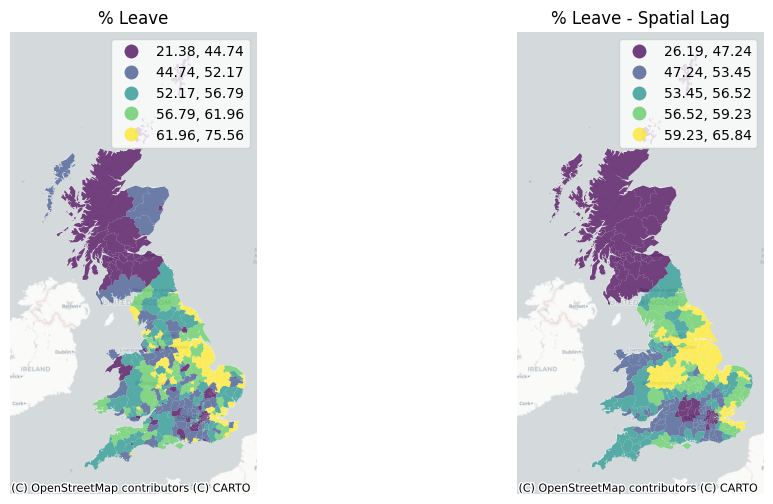

In [12]:
f, axs = plt.subplots(1, 2, figsize=(12, 6))
ax1, ax2 = axs

db.plot(
    column="Pct_Leave",
    cmap="viridis",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.0,
    alpha=0.75,
    legend=True,
    ax=ax1,
)
ax1.set_axis_off()
ax1.set_title("% Leave")
contextily.add_basemap(
    ax1,
    crs=db.crs,
    source=contextily.providers.CartoDB.Positron,
)

db.plot(
    column="Pct_Leave_lag",
    cmap="viridis",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.0,
    alpha=0.75,
    legend=True,
    ax=ax2,
)
ax2.set_axis_off()
ax2.set_title("% Leave - Spatial Lag")
contextily.add_basemap(
    ax2,
    crs=db.crs,
    source=contextily.providers.CartoDB.Positron,
)

plt.show()

El rezago espacial suaviza las diferencias abruptas del mapa original. Las zonas atípicas (como Liverpool, aislada en medio de vecinos con alto % Leave) se atenúan en el mapa de la derecha.

**NOTA:** El parámetro k en weights.KNN (k=8) define el número de vecinos
para construir la matriz de pesos espaciales.El parámetro k en db.plot (k=5) define el número de clases en el esquema de clasificación (EqualInterval).


## 3.2 Caso binario: *Join Counts* (conteo de uniones)

Antes de abordar el caso continuo, es útil comenzar con una versión simplificada: variables **binarias**, que solo toman dos valores. En nuestro caso, nos interesa saber si las autoridades locales que votaron Leave tienden a estar rodeadas de otras que también votaron Leave.

Para eso, primero transformamos `Pct_Leave` en una variable binaria: vale **1** si el porcentaje es mayor a 50 (mayoría Leave) y **0** en caso contrario.



In [13]:
# Crear variable binaria: 1 si el % Leave > 50
db["Leave"] = (db["Pct_Leave"] > 50).astype(int)
db[["Pct_Leave", "Leave"]].tail()

,Pct_Leave,Leave
lad16cd,,
W06000018,57.63,1
W06000019,62.03,1
W06000021,49.56,0
W06000022,55.99,1
W06000023,53.74,1


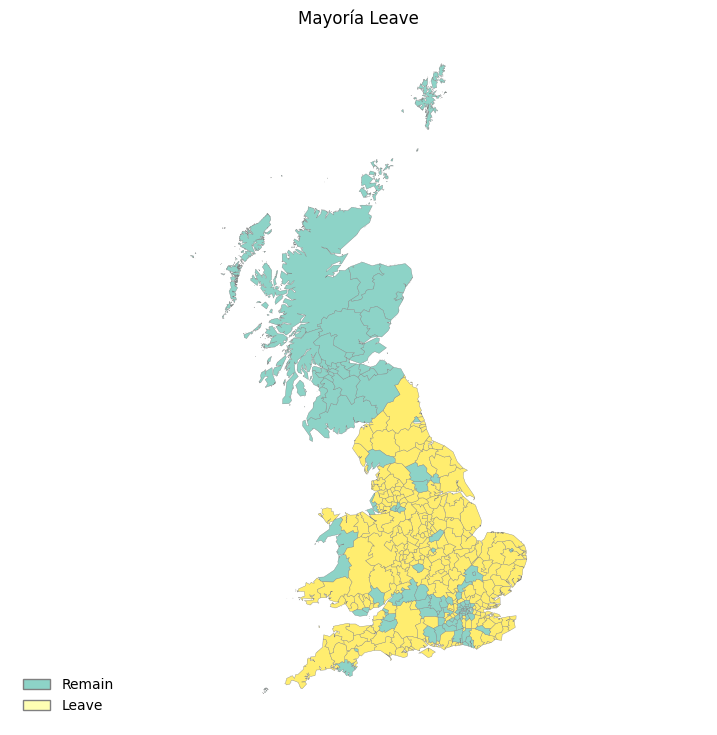

In [26]:
from matplotlib.patches import Patch

f, ax = plt.subplots(1, figsize=(9, 9))
db.plot(
    ax=ax,
    column="Leave",
    categorical=True,
    edgecolor="0.5",
    linewidth=0.25,
    cmap="Set3",
)
ax.set_axis_off()
ax.set_title("Mayoría Leave")
plt.axis("equal")

colors = [plt.cm.Set3(0), plt.cm.Set3(1/11)]
legend_elements = [Patch(facecolor=colors[0], edgecolor="0.5", label="Remain"),
                   Patch(facecolor=colors[1], edgecolor="0.5", label="Leave")]
ax.legend(handles=legend_elements, loc="lower left", frameon=False)

plt.show()

El estadístico de **Join Counts** funciona con la metáfora de un tablero de ajedrez con casillas de dos colores:
- **Verde (G = 0):** autoridad con mayoría Remain
- **Amarillo (A = 1):** autoridad con mayoría Leave

El estadístico cuenta los pares vecinos (*joins*) de cada tipo:

| Tipo de unión | Descripción | Señal |
|---------------|-------------|-------|
| GG (verde-verde) | Dos vecinos Remain | Autocorrelación positiva |
| AA (amarillo-amarillo) | Dos vecinos Leave | Autocorrelación positiva |
| GA (verde-amarillo) | Vecinos opuestos | Autocorrelación negativa |

La lógica es comparar lo observado con lo que esperaríamos bajo **aleatoriedad espacial completa** (hipótesis nula): si los valores estuvieran distribuidos al azar en el mapa, ¿cuántos GG, AA y GA esperaríamos ver? Si observamos **más GG/AA de lo esperado y menos GA**, hay evidencia de autocorrelación espacial positiva.

El mapa muestra que las regiones Leave (color verde claro) dominan el centro, norte y este de Inglaterra, mientras que las regiones Remain (verde oscuro) se concentran en Londres, Escocia y algunas ciudades del norte como Liverpool. A simple vista ya se aprecia agrupamiento espacial — pero necesitamos cuantificarlo formalmente.

**Nota importante:** Join Counts requiere una matriz de pesos **binaria** (no estandarizada por filas). Por eso a continuación revertimos la estandarización de `w`.

In [27]:
# Join Counts requiere pesos binarios (no estandarizados)
w.transform = "O"

In [28]:
# Calcular Join Counts
seed(1234)
jc = esda.join_counts.Join_Counts(db["Leave"], w)

### Atributos del objeto `jc`

`Join_Counts` devuelve un objeto con varios atributos. Los principales son:

| Atributo | Descripción |
|----------|-------------|
| `jc.bb` | Uniones observadas entre pares (0-0): dos vecinos Remain |
| `jc.ww` | Uniones observadas entre pares (1-1): dos vecinos Leave |
| `jc.bw` | Uniones observadas entre pares (0-1): vecinos de categoría opuesta |
| `jc.J` | Total de uniones (`bb + ww + bw`) |
| `jc.mean_bb` | Uniones (0-0) esperadas bajo aleatoriedad espacial |
| `jc.mean_bw` | Uniones (0-1) esperadas bajo aleatoriedad espacial |
| `jc.p_sim_bb` | Pseudo p-valor para uniones de misma categoría |
| `jc.p_sim_bw` | Pseudo p-valor para uniones de categoría opuesta |

Los nombres `bb` y `ww` vienen de la nomenclatura original del estadístico,
donde las dos categorías eran **b**lack y **w**hite. En nuestro caso,
`bb` corresponde a pares Remain-Remain y `ww` a pares Leave-Leave.

In [29]:
# Resultados: conteo de uniones observadas
print(f"Uniones GG (0-0): {jc.bb}")
print(f"Uniones AA (1-1): {jc.ww}")
print(f"Uniones GA (0-1): {jc.bw}")
print(f"Total de uniones: {jc.J}")


Uniones GG (0-0): 871.0
Uniones AA (1-1): 302.0
Uniones GA (0-1): 347.0
Total de uniones: 1520.0


In [18]:
# Valores esperados bajo aleatoriedad espacial
print(f"Uniones GG esperadas: {jc.mean_bb:.1f}")
print(f"Uniones GA esperadas: {jc.mean_bw:.1f}")

Uniones GG esperadas: 727.4
Uniones GA esperadas: 649.3


In [34]:
# Pseudo p-valores (prueba de significancia mediante permutaciones)
print(f"P-valor para uniones misma categoría (GG): {jc.p_sim_bb:.4f}")
print(f"P-valor para uniones distinta categoría (GA): {jc.p_sim_bw:.4f}")

P-valor para uniones misma categoría (GG): 0.0010
P-valor para uniones distinta categoría (GA): 1.0000


### Interpretando los resultados

PySAL calcula los pseudo p-valores con la fórmula:

$$p = \frac{r + 1}{999 + 1}$$

Donde $r$ es el número de permutaciones que obtuvieron un valor mayor o
igual al observado.

- `p_sim_bb = 0.001` → ninguna permutación tuvo tantas uniones de misma
  categoría como las observadas: $(0 + 1) / (999 + 1) = 0.001$.
  Hay **más** agrupamiento del que el azar produciría.

- `p_sim_bw = 1.0` → todas las permutaciones tuvieron más uniones de
  categorías opuestas que las observadas: $(999 + 1) / (999 + 1) = 1.0$.
  Hay **menos** mezcla Leave-Remain de la que el azar produciría.

Ambos resultados apuntan en la misma dirección: los valores similares se
agrupan geográficamente — el patrón observado en el mapa no es producto
del azar.

## 3.3 Caso continuo: Gráfico de Moran e I de Moran

Join Counts funciona bien para variables binarias, pero `Pct_Leave` es una variable **continua** que va de 0 a 100. Para este caso, el estadístico más utilizado es el **I de Moran**, formulado como:

$$I = \frac{n}{\sum_i \sum_j w_{ij}} \cdot \frac{\sum_i \sum_j w_{ij} \, z_i \, z_j}{\sum_i z_i^2}$$

Donde:
- $n$ = número de observaciones
- $z_i = y_i - \bar{y}$ es el valor **centrado en la media** (cuánto se aleja cada área del promedio nacional)
- $w_{ij}$ es la celda de la matriz de pesos para el par $i$, $j$

La fórmula es esencialmente un **coeficiente de correlación espacial**: mide si los valores altos (o bajos) de $z_i$ en una localización tienden a estar rodeados de valores también altos (o bajos) en sus vecinos $z_j$. El producto $z_i \cdot z_j$ es positivo cuando ambos están del mismo lado de la media, y negativo cuando están en lados opuestos.

**Valores de referencia:**
- $I \approx 0$: aleatoriedad espacial (valor esperado bajo la hipótesis nula)
- $I > 0$: autocorrelación positiva (valores similares se agrupan)
- $I < 0$: autocorrelación negativa (valores distintos se alternan)

### Gráfico de Moran (*Moran Plot*)

Antes de calcular el estadístico numéricamente, es útil visualizarlo. El **Gráfico de Moran** es un diagrama de dispersión que enfrenta:
- **Eje X:** el valor estandarizado (centrado) de la variable en cada área
- **Eje Y:** el rezago espacial estandarizado — es decir, el promedio de los vecinos

La **pendiente de la recta de regresión** en este gráfico es exactamente el I de Moran. Los cuatro cuadrantes del gráfico tienen una interpretación geográfica directa:

| Cuadrante | Valor propio | Valor vecinos | Tipo |
|-----------|--------------|---------------|------|
| Alto-Alto (++, arriba derecha) | > media | > media | Cluster positivo Leave |
| Bajo-Bajo (--, abajo izquierda) | < media | < media | Cluster positivo Remain |
| Alto-Bajo (+-, abajo derecha) | > media | < media | Outlier espacial |
| Bajo-Alto (-+, arriba izquierda) | < media | > media | Outlier espacial |

Para construirlo, primero centramos la variable en su media:

In [20]:
# Estandarizar la variable (restar la media)
db["Pct_Leave_std"] = db["Pct_Leave"] - db["Pct_Leave"].mean()

# Calcular el rezago espacial de la variable estandarizada
db["Pct_Leave_lag_std"] = weights.lag_spatial(
    w, db["Pct_Leave_std"]
)

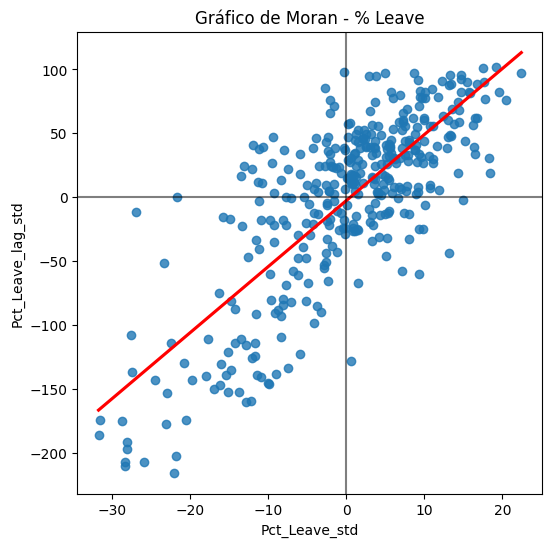

In [21]:
# Gráfico de Moran
f, ax = plt.subplots(1, figsize=(6, 6))
seaborn.regplot(
    x="Pct_Leave_std",
    y="Pct_Leave_lag_std",
    ci=None,
    data=db,
    line_kws={"color": "r"},
)
ax.axvline(0, c="k", alpha=0.5)
ax.axhline(0, c="k", alpha=0.5)
ax.set_title("Gráfico de Moran - % Leave")
plt.show()

El gráfico muestra una **relación positiva clara**: cuando una autoridad local tiene un porcentaje Leave por encima de la media nacional (eje X positivo), sus vecinos también tienden a tener valores por encima de la media (eje Y positivo). Lo mismo ocurre hacia abajo: áreas con bajo Leave están rodeadas de áreas también con bajo Leave.

La mayoría de los puntos se concentran en los cuadrantes Alto-Alto y Bajo-Bajo, lo que confirma el patrón de agrupamiento que observamos en el mapa. Los puntos en los cuadrantes Alto-Bajo y Bajo-Alto representan **outliers espaciales**: áreas que votan distinto a sus vecinos — Liverpool es el ejemplo más conocido.

Ahora calculamos el I de Moran formalmente. Primero restauramos la estandarización por filas de `w`, que necesitamos para el cálculo:

In [22]:
# Calcular I de Moran formalmente
w.transform = "R"
moran = esda.moran.Moran(db["Pct_Leave"], w)

In [23]:
# Valor del estadístico
print(f"I de Moran: {moran.I:.4f}")

I de Moran: 0.6455


In [24]:
# Pseudo p-valor (significancia estadística)
print(f"Pseudo p-valor: {moran.p_sim:.4f}")

Pseudo p-valor: 0.0010


El **pseudo p-valor** se obtiene mediante el mismo mecanismo de permutaciones que en Join Counts: PySAL genera 999 mapas aleatorios redistribuyendo los valores de `Pct_Leave` en las áreas, calcula el I de Moran en cada uno, y construye una distribución de referencia bajo aleatoriedad.

Un p-valor de 0.001 significa que ninguno de los 999 mapas aleatorios produjo un I de Moran tan alto como el observado. En otras palabras, es **virtualmente imposible** que el patrón geográfico que vemos sea producto del azar.

El valor del I de Moran (~0.62) también tiene interpretación sustantiva: indica una **autocorrelación espacial positiva fuerte**. El porcentaje de voto Leave no está distribuido aleatoriamente en el territorio — hay una estructura geográfica clara y significativa.

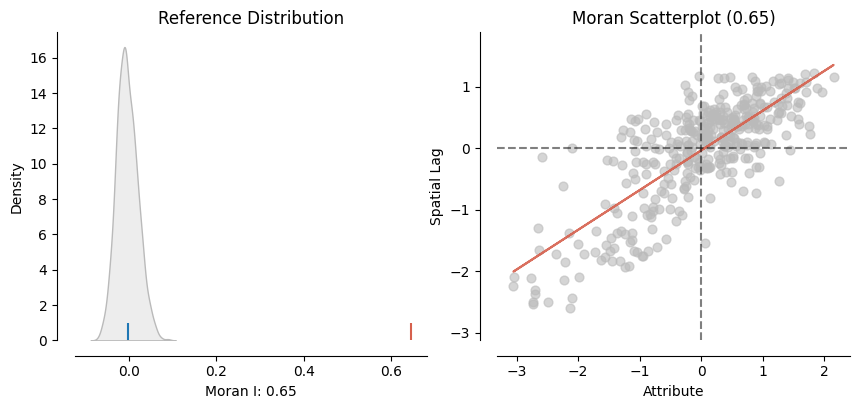

In [25]:
# Visualización combinada con splot
plot_moran(moran);

La visualización combinada muestra dos paneles complementarios:

- **Panel izquierdo (distribución de referencia):** Histograma del I de Moran calculado en las 999 permutaciones aleatorias (distribución bajo H₀: aleatoriedad espacial). La barra azul marca la media de esa distribución (~0), y la barra roja indica el I de Moran **observado** en los datos reales. El valor observado está muy alejado de la distribución de aleatoriedad, lo que confirma la significancia estadística.

- **Panel derecho:** El Gráfico de Moran que ya construimos anteriormente.

Juntos, estos dos paneles son la forma estándar de reportar el I de Moran en análisis espacial: el número por sí solo no basta — también hay que mostrar que es estadísticamente distinguible del ruido aleatorio.